<a href="https://colab.research.google.com/github/JorgeCaldeira/Beware-the-dog/blob/main/DL_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##TODO
Please add max 2 pages to the report of Milestone 0 with:

*   data pipeline, including preprocessing
baseline description:

    *  model name / architecture depth;
    *  input shape;
    *  loss;
    *  optimiser;
    *  training budget (epochs, LR, batch, GPU time)


* preliminary results and training curves
* known issues and next steps, including a detailed plan for the rest of the experiments






By the first milestone, it is expected that you have the data downloaded and ready to be used, the models clearly identified and a skeleton code to start working on.

This time, the document should be 3 pages max and it can include whatever is still relevant from the proposal. It should have:
* Title, group members
* Introduction: this section introduces your problem, and the overall plan for approaching your problem
* Problem statement: Describe your problem precisely specifying the dataset to be used, expected results and evaluation
* Technical Approach: Describe the methods you intend to apply to solve the given problem
* Figure describing the approach / methodology.

Get inspiration from the papers that you’re reading for your project. Some examples:
figure 1 of this paper or similar
check the posters here or go check LASIGE posters in C6 floor 2.
Describe the experiments you are planning to do and preliminary results if you have them.



In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import os

In [21]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
#for root, dirs, files in os.walk('/content/drive'):
#    if 'dog-breed-identification' in root:
#        print(root)

In [23]:
import os
os.chdir('/content/drive/MyDrive/AP Projeto/dog-breed-identification')

In [24]:
#!ls "/content/drive/MyDrive/AP Projeto/dog-breed-identification/"

In [25]:
#!zip -r train.zip train

In [26]:
!cp "/content/drive/MyDrive/AP Projeto/dog-breed-identification/train.zip" /content/train.zip
!unzip -q /content/train.zip -d /content/train_local

replace /content/train_local/train/e8d0712b9ca47f77b333858183a38ef7.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/train_local/train/e7faa5748d8320f604aeb3fd5bbe4ab0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/train_local/train/e87a86f29c8709e81bbea9c8139d739c.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/train_local/train/e7f6ec634384c07f7a0f5659e4f77867.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/train_local/train/e79a196a6e1772b9fa6b008b597d3a08.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/train_local/train/e7fda54b5e96c6048dad68414568f142.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/train_local/train/e74f33ae3d78d3d2f8c75b8fc847f5ad.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/train_local/train/e7678fac0b8f1d97e742644ee75a8aa2.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/train_local/train/e80dbb78fb1d763d01d73b2f367c6805.jpg? [y]es, [n]o, [A]ll, [N]

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score


labels_df = pd.read_csv('labels.csv')
breed_list = sorted(labels_df['breed'].unique())
breed_to_idx = {breed: i for i, breed in enumerate(breed_list)}
train_df, val_df = train_test_split(labels_df, test_size=0.2, random_state=42, stratify=labels_df['breed'])

class DogDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.iloc[idx, 0]
        breed_name = self.dataframe.iloc[idx, 1]
        label = breed_to_idx[breed_name]

        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [28]:
print(f"Total number of images in train set: {len(train_df)}")
print(f"Total number of images in validation set: {len(val_df)}")
print(f"Average of images per class in validation set: {val_df['breed'].value_counts().mean():.2f}")

Total number of images in train set: 8177
Total number of images in validation set: 2045
Average of images per class in validation set: 17.04


Augmentation e baseline transforms

In [29]:
imagenet_normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    imagenet_normalization
])

augmented_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    imagenet_normalization
])

Funcao para validar o modelo

In [30]:
def validate_model(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            total += labels.size(0)

            # Top-1 Accuracy
            _, predicted = outputs.max(1)
            correct_top1 += predicted.eq(labels).sum().item()

            # Top-5 Accuracy
            _, top5_preds = outputs.topk(5, 1, True, True)
            correct_top5 += top5_preds.eq(labels.view(-1, 1).expand_as(top5_preds)).sum().item()

            # F1
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = val_loss / total
    acc_top1 = 100. * correct_top1 / total
    acc_top5 = 100. * correct_top5 / total
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc_top1, acc_top5, macro_f1

In [33]:
def initialize_model(model_name="resnet50", num_classes=120, mode="freeze"):
    if model_name == "resnet50":
        model = models.resnet50(weights='DEFAULT')

    if mode == "freeze":
        print("Setup: RESNET50 (FREEZE)")
        for param in model.parameters():
            param.requires_grad = False

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

    elif mode == "partial_finetune":
        print("Setup: RESNET50 (PARTIAL_FINETUNE)")
        for param in model.parameters():
            param.requires_grad = False

        for param in model.layer4.parameters():
            param.requires_grad = True

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    model.fc.weight.requires_grad = True
    model.fc.bias.requires_grad = True

    #O professor pediu para reportarmos o numero de parametros ativos e assim isto conta-os
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Frozen Parameters: {frozen_params:,}")
    print("-" * 30)

    return model

COM AUGMENTED:

usamos o train de augmented para treinar assim e o val usamos o baseline(para testar se aprendeu caracteriristicas ou decorou coisas)

Using: cuda
Setup: RESNET50 (FREEZE)
Total Parameters: 23,753,912
Trainable Parameters: 245,880
Frozen Parameters: 23,508,032
------------------------------
Epoch 1/20:
  [TRAIN] Loss: 4.5589 | Acc: 11.12%
  [VALID] Loss: 4.2535 | Top-1: 35.70% | Top-5: 73.74% | F1: 0.3130
------------------------------
Epoch 2/20:
  [TRAIN] Loss: 4.1328 | Acc: 32.18%
  [VALID] Loss: 3.8342 | Top-1: 55.60% | Top-5: 88.75% | F1: 0.5193
------------------------------
Epoch 3/20:
  [TRAIN] Loss: 3.7828 | Acc: 44.16%
  [VALID] Loss: 3.4596 | Top-1: 64.89% | Top-5: 92.67% | F1: 0.6218
------------------------------
Epoch 4/20:
  [TRAIN] Loss: 3.4984 | Acc: 48.71%
  [VALID] Loss: 3.1212 | Top-1: 69.78% | Top-5: 94.28% | F1: 0.6740
------------------------------
Epoch 5/20:
  [TRAIN] Loss: 3.2445 | Acc: 52.20%
  [VALID] Loss: 2.8219 | Top-1: 72.08% | Top-5: 95.01% | F1: 0.7003
------------------------------
Epoch 6/20:
  [TRAIN] Loss: 3.0219 | Acc: 54.24%
  [VALID] Loss: 2.5722 | Top-1: 74.67% | Top-5: 95.84%

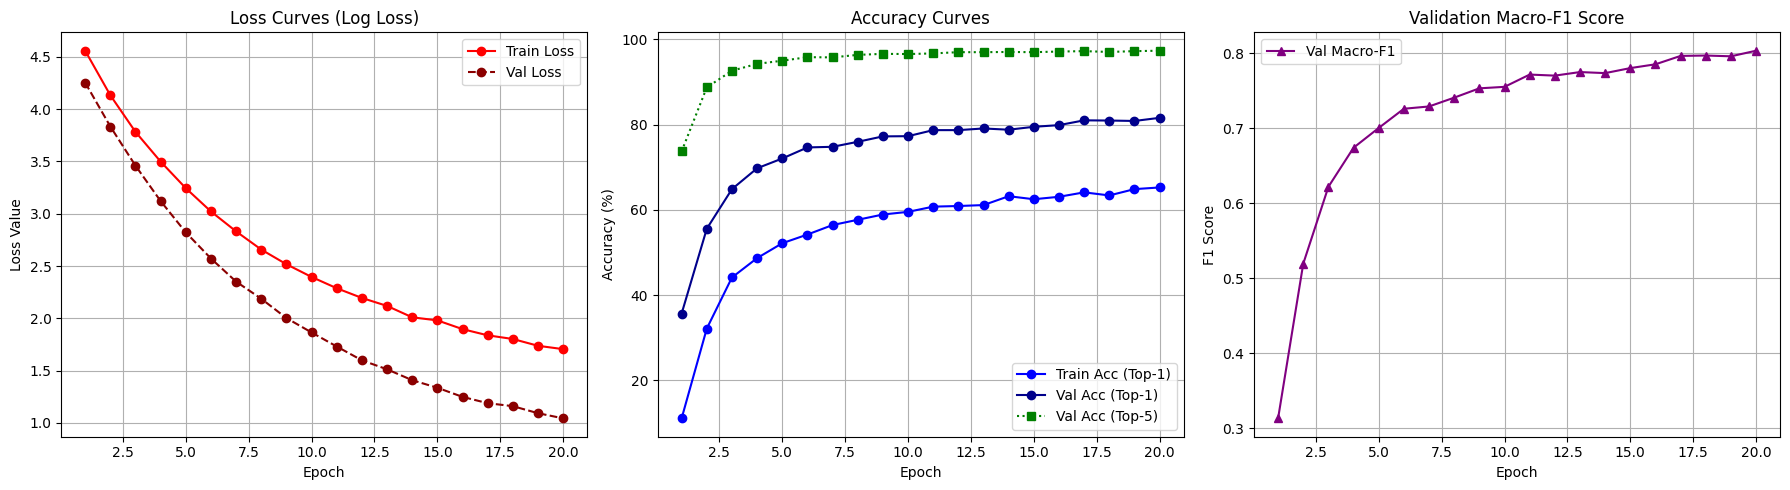

In [34]:
train_set = DogDataset(train_df, '/content/train_local/train/', transform=augmented_transform)
val_set = DogDataset(val_df, '/content/train_local/train/', transform=baseline_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True) # pin memory e num_workers deixa um bocado mais rapido
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # para usar o t4 do colab
print(f"Using: {device}")

train_losses, val_losses = [], []
train_accs, val_accs_top1, val_accs_top5 = [], [], []
val_f1_history = []

dog_model = initialize_model("resnet50", num_classes=120, mode="freeze").to(device)
criterion = nn.CrossEntropyLoss() # na semana 3 isto é mencionado
optimizer = optim.Adam(dog_model.fc.parameters(), lr=0.0001)

num_epochs = 20

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device) # treinar
    v_loss, v_top1, v_top5, v_f1 = validate_model(dog_model, val_loader, criterion, device) #validar

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs_top1.append(v_top1)
    val_accs_top5.append(v_top5)
    val_f1_history.append(v_f1)

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  [TRAIN] Loss: {t_loss:.4f} | Acc: {t_acc:.2f}%")
    print(f"  [VALID] Loss: {v_loss:.4f} | Top-1: {v_top1:.2f}% | Top-5: {v_top5:.2f}% | F1: {v_f1:.4f}")
    print("-" * 30)

#FAZER PLOTS PARA TREINO E TEST (Baseline)
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o', color='red')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss', marker='o', linestyle='--', color='darkred')
plt.title('Loss Curves (Log Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Train Acc (Top-1)', marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), val_accs_top1, label='Val Acc (Top-1)', marker='o', color='darkblue')
plt.plot(range(1, num_epochs + 1), val_accs_top5, label='Val Acc (Top-5)', marker='s', linestyle=':', color='green')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), val_f1_history, label='Val Macro-F1', marker='^', color='purple')
plt.title('Validation Macro-F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [35]:
# Limpar memorias e wtv para nao dar problemas de out of memory ehntre os dois
import gc

del dog_model
del optimizer
torch.cuda.empty_cache()
gc.collect()

36050

USING BASELINE

Setup: RESNET50 (FREEZE)
Total Parameters: 23,753,912
Trainable Parameters: 245,880
Frozen Parameters: 23,508,032
------------------------------
Epoch 1/20:
  [TRAIN] Loss: 4.4284 | Acc: 17.46%
  [VALID] Loss: 4.1004 | Top-1: 41.61% | Top-5: 80.20% | F1: 0.3858
------------------------------
Epoch 2/20:
  [TRAIN] Loss: 3.7257 | Acc: 59.24%
  [VALID] Loss: 3.5501 | Top-1: 64.94% | Top-5: 93.79% | F1: 0.6276
------------------------------
Epoch 3/20:
  [TRAIN] Loss: 3.1551 | Acc: 72.43%
  [VALID] Loss: 3.0834 | Top-1: 72.57% | Top-5: 95.84% | F1: 0.7073
------------------------------
Epoch 4/20:
  [TRAIN] Loss: 2.6741 | Acc: 79.43%
  [VALID] Loss: 2.6841 | Top-1: 75.16% | Top-5: 96.43% | F1: 0.7327
------------------------------
Epoch 5/20:
  [TRAIN] Loss: 2.2735 | Acc: 83.16%
  [VALID] Loss: 2.3549 | Top-1: 77.07% | Top-5: 97.02% | F1: 0.7526
------------------------------
Epoch 6/20:
  [TRAIN] Loss: 1.9406 | Acc: 84.84%
  [VALID] Loss: 2.1094 | Top-1: 78.19% | Top-5: 97.21% | F1: 0.765

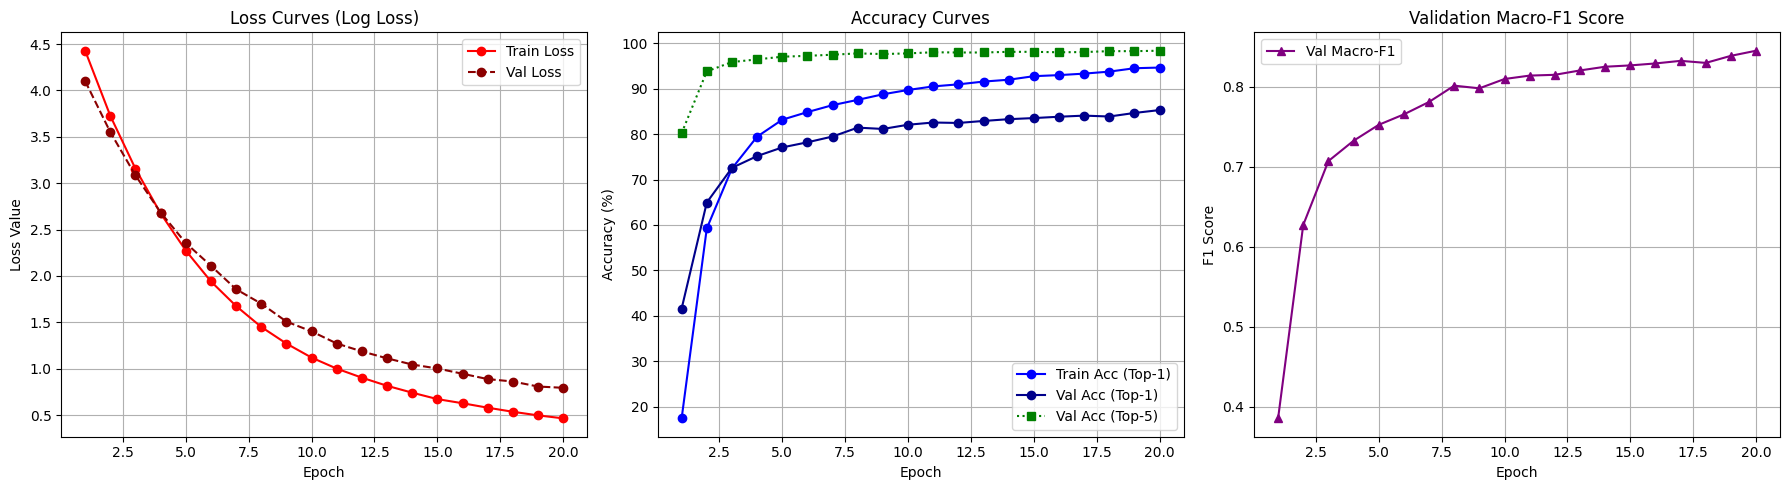

In [36]:
train_set = DogDataset(train_df, '/content/train_local/train/', transform=baseline_transform)
val_set = DogDataset(val_df, '/content/train_local/train/', transform=baseline_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True) # pin memory e num_workers deixa um bocado mais rapido
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # para usar o t4 do colab

train_losses, val_losses = [], []
train_accs, val_accs_top1, val_accs_top5 = [], [], []
val_f1_history = []

dog_model = initialize_model("resnet50", num_classes=120, mode="freeze").to(device)
criterion = nn.CrossEntropyLoss() # na semana 3 isto é mencionado
optimizer = optim.Adam(dog_model.fc.parameters(), lr=0.0001)

num_epochs = 20

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device) # treinar
    v_loss, v_top1, v_top5, v_f1 = validate_model(dog_model, val_loader, criterion, device) #validar

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs_top1.append(v_top1)
    val_accs_top5.append(v_top5)
    val_f1_history.append(v_f1)

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  [TRAIN] Loss: {t_loss:.4f} | Acc: {t_acc:.2f}%")
    print(f"  [VALID] Loss: {v_loss:.4f} | Top-1: {v_top1:.2f}% | Top-5: {v_top5:.2f}% | F1: {v_f1:.4f}")
    print("-" * 30)

#FAZER PLOTS PARA TREINO E TEST (Baseline)
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o', color='red')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss', marker='o', linestyle='--', color='darkred')
plt.title('Loss Curves (Log Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Train Acc (Top-1)', marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), val_accs_top1, label='Val Acc (Top-1)', marker='o', color='darkblue')
plt.plot(range(1, num_epochs + 1), val_accs_top5, label='Val Acc (Top-5)', marker='s', linestyle=':', color='green')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), val_f1_history, label='Val Macro-F1', marker='^', color='purple')
plt.title('Validation Macro-F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Baseline treinado a ver imagens que podem por vezes ser rodadas ou wtv como validation (esperamos resultados piores do que treinar com augmented e testar no baseline)

Setup: RESNET50 (FREEZE)
Total Parameters: 23,753,912
Trainable Parameters: 245,880
Frozen Parameters: 23,508,032
------------------------------
Epoch 1/20:
  [TRAIN] Loss: 4.4232 | Acc: 18.14%
  [VALID] Loss: 4.3363 | Top-1: 15.60% | Top-5: 41.47% | F1: 0.1476
------------------------------
Epoch 2/20:
  [TRAIN] Loss: 3.7184 | Acc: 58.02%
  [VALID] Loss: 3.9774 | Top-1: 27.92% | Top-5: 56.48% | F1: 0.2739
------------------------------
Epoch 3/20:
  [TRAIN] Loss: 3.1444 | Acc: 74.53%
  [VALID] Loss: 3.6705 | Top-1: 31.25% | Top-5: 60.93% | F1: 0.3111
------------------------------
Epoch 4/20:
  [TRAIN] Loss: 2.6625 | Acc: 79.64%
  [VALID] Loss: 3.4625 | Top-1: 33.94% | Top-5: 62.25% | F1: 0.3425
------------------------------
Epoch 5/20:
  [TRAIN] Loss: 2.2671 | Acc: 82.96%
  [VALID] Loss: 3.2690 | Top-1: 36.48% | Top-5: 63.37% | F1: 0.3781
------------------------------
Epoch 6/20:
  [TRAIN] Loss: 1.9323 | Acc: 84.80%
  [VALID] Loss: 3.1673 | Top-1: 36.43% | Top-5: 64.11% | F1: 0.378

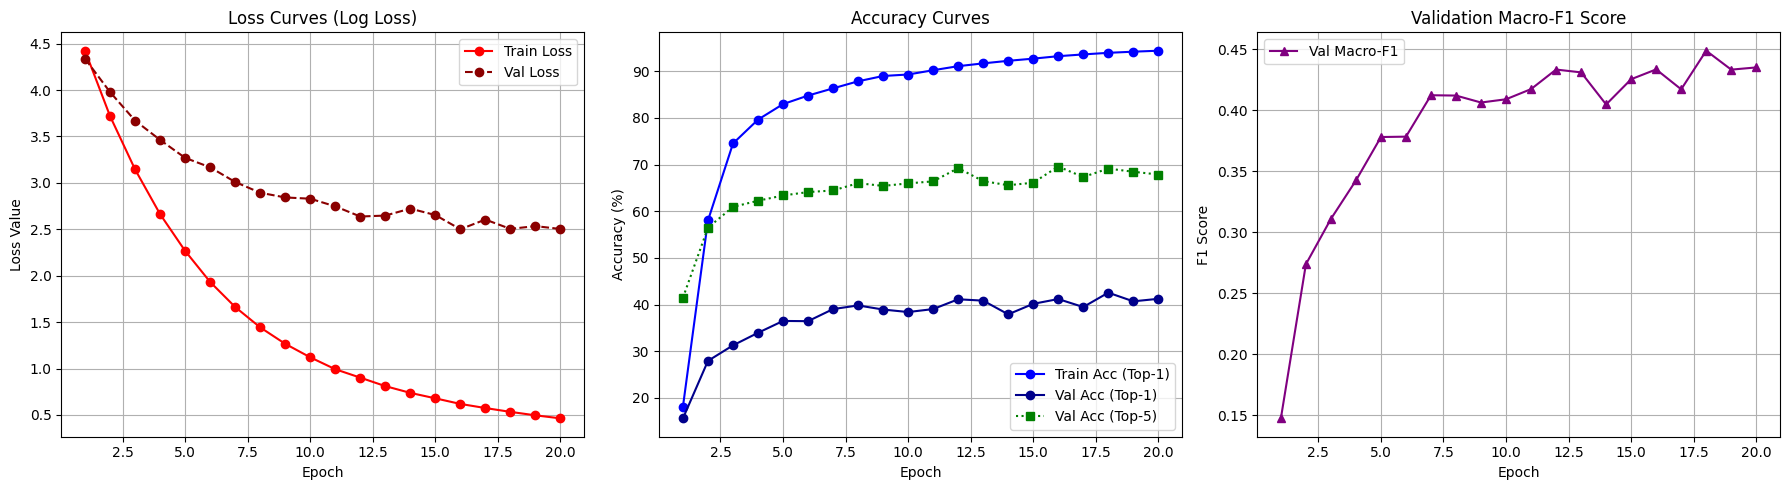

In [37]:
train_set = DogDataset(train_df, '/content/train_local/train/', transform=baseline_transform)
val_set = DogDataset(val_df, '/content/train_local/train/', transform=augmented_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True) # pin memory e num_workers deixa um bocado mais rapido
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # para usar o t4 do colab

train_losses, val_losses = [], []
train_accs, val_accs_top1, val_accs_top5 = [], [], []
val_f1_history = []

dog_model = initialize_model("resnet50", num_classes=120, mode="freeze").to(device)
criterion = nn.CrossEntropyLoss() # na semana 3 isto é mencionado
optimizer = optim.Adam(dog_model.fc.parameters(), lr=0.0001)

num_epochs = 20

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device) # treinar
    v_loss, v_top1, v_top5, v_f1 = validate_model(dog_model, val_loader, criterion, device) #validar

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs_top1.append(v_top1)
    val_accs_top5.append(v_top5)
    val_f1_history.append(v_f1)

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  [TRAIN] Loss: {t_loss:.4f} | Acc: {t_acc:.2f}%")
    print(f"  [VALID] Loss: {v_loss:.4f} | Top-1: {v_top1:.2f}% | Top-5: {v_top5:.2f}% | F1: {v_f1:.4f}")
    print("-" * 30)

#FAZER PLOTS PARA TREINO E TEST (Baseline)
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o', color='red')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss', marker='o', linestyle='--', color='darkred')
plt.title('Loss Curves (Log Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Train Acc (Top-1)', marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), val_accs_top1, label='Val Acc (Top-1)', marker='o', color='darkblue')
plt.plot(range(1, num_epochs + 1), val_accs_top5, label='Val Acc (Top-5)', marker='s', linestyle=':', color='green')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), val_f1_history, label='Val Macro-F1', marker='^', color='purple')
plt.title('Validation Macro-F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

milestone 2(ja tem algumas modificacoes atras necessarias)

Using: cuda
Setup: RESNET50 (PARTIAL_FINETUNE)
Total Parameters:23,753,912
Trainable Parameters:15,192,184
Frozen Parameters:8,561,728
Batch Normalization:Frozen (evaluation mode)

--- A iniciar execução controlada do Fine-Tuning Parcial ---
Epoch 1/20:
  [TRAIN] Loss: 3.3566 | Acc: 31.44%
  [VALID] Loss: 1.1055 | Top-1: 75.26% | Top-5: 96.77% | F1: 0.7342
------------------------------
Epoch 2/20:
  [TRAIN] Loss: 1.7561 | Acc: 57.58%
  [VALID] Loss: 0.7488 | Top-1: 78.88% | Top-5: 96.87% | F1: 0.7742
------------------------------
Epoch 3/20:
  [TRAIN] Loss: 1.4614 | Acc: 62.28%
  [VALID] Loss: 0.6926 | Top-1: 78.83% | Top-5: 97.07% | F1: 0.7714
------------------------------
Epoch 4/20:
  [TRAIN] Loss: 1.3363 | Acc: 65.33%
  [VALID] Loss: 0.6371 | Top-1: 80.98% | Top-5: 97.85% | F1: 0.7978
------------------------------
Epoch 5/20:
  [TRAIN] Loss: 1.2622 | Acc: 66.19%
  [VALID] Loss: 0.6320 | Top-1: 80.73% | Top-5: 97.56% | F1: 0.8006
------------------------------
Epoch 6/20:
  [TRA

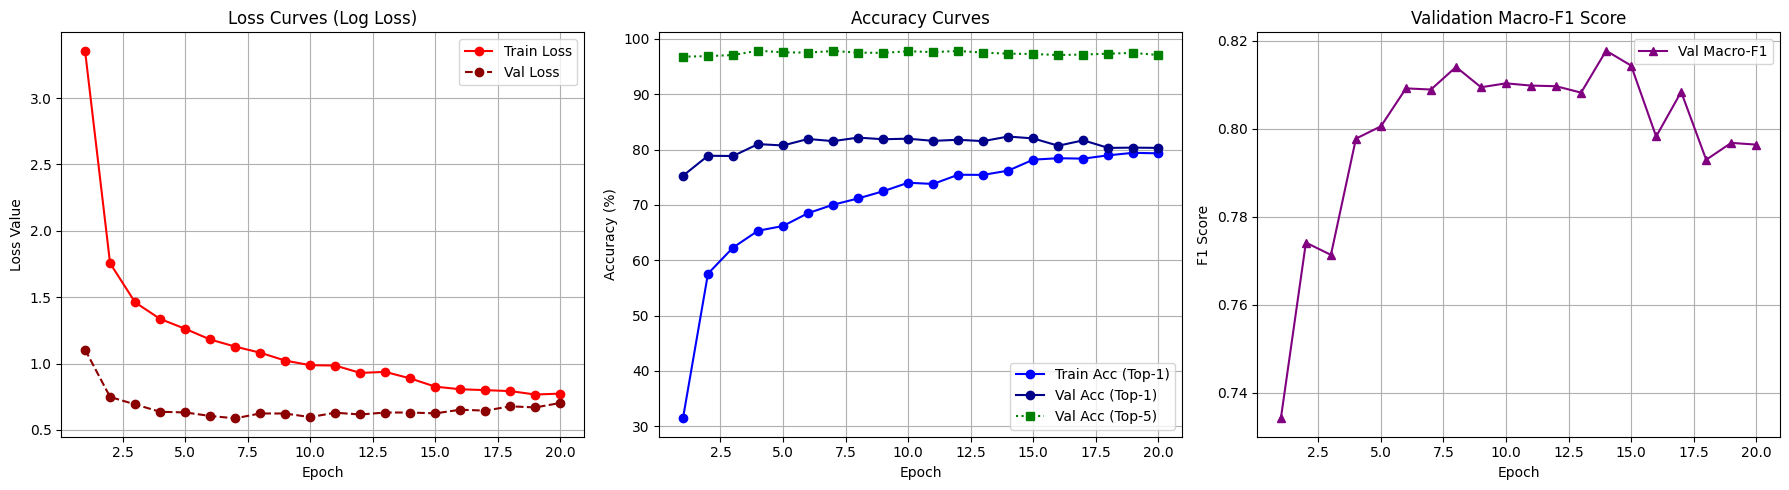

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm # ver uma barra de progresso
from sklearn.metrics import f1_score

#definido again para nao ter de correr celulas de cima que tem mais coisas para correr para conseguir testar esta parte mais rapidamente
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #limpar para n usar anteriores
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    return epoch_loss, epoch_acc

#definido again para nao ter de correr celulas de cima que tem mais coisas para correr para conseguir testar esta parte mais rapidamente
def validate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            total += labels.size(0)

            _, predicted = outputs.max(1)
            correct_top1 += predicted.eq(labels).sum().item()

            _, top5_predicted = outputs.topk(5, 1, True, True)
            correct_top5 += top5_predicted.eq(labels.view(-1, 1).expand_as(top5_predicted)).sum().item()

            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    val_loss = running_loss / total
    val_top1 = (correct_top1 / total) * 100
    val_top5 = (correct_top5 / total) * 100

    return val_loss, val_top1, val_top5, macro_f1 #as metricas que ja usamos na milestone anterior


train_set = DogDataset(train_df, '/content/train_local/train/', transform=augmented_transform) #usar o "limpo" em que temos o augemted a train e o baseline como validation
val_set = DogDataset(val_df, '/content/train_local/train/', transform=baseline_transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

train_losses, val_losses = [], []
train_accs, val_accs_top1, val_accs_top5 = [], [], []
val_f1_history = []

dog_model = initialize_model("resnet50", num_classes=120, mode="partial_finetune") #usar o partial fine tuning
dog_model = dog_model.to(device)

criterion = nn.CrossEntropyLoss()

# Passar todos os ativos filtrados
optimizer = optim.Adam(filter(lambda p: p.requires_grad, dog_model.parameters()), lr=0.0001)

num_epochs = 20

for epoch in range(num_epochs):
    t_loss, t_acc = train_epoch(dog_model, train_loader, criterion, optimizer, device)
    v_loss, v_top1, v_top5, v_f1 = validate_model(dog_model, val_loader, criterion, device)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs_top1.append(v_top1)
    val_accs_top5.append(v_top5)
    val_f1_history.append(v_f1)

    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  [TRAIN] Loss: {t_loss:.4f} | Acc: {t_acc:.2f}%")
    print(f"  [VALID] Loss: {v_loss:.4f} | Top-1: {v_top1:.2f}% | Top-5: {v_top5:.2f}% | F1: {v_f1:.4f}")


plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o', color='red')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss', marker='o', linestyle='--', color='darkred')
plt.title('Loss Curves (Log Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(range(1, num_epochs + 1), train_accs, label='Train Acc (Top-1)', marker='o', color='blue')
plt.plot(range(1, num_epochs + 1), val_accs_top1, label='Val Acc (Top-1)', marker='o', color='darkblue')
plt.plot(range(1, num_epochs + 1), val_accs_top5, label='Val Acc (Top-5)', marker='s', linestyle=':', color='green')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(range(1, num_epochs + 1), val_f1_history, label='Val Macro-F1', marker='^', color='purple')
plt.title('Validation Macro-F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()